In this notebook, we explore using the SSL model to find weird ones.

The image size is 152x152 pixels, make the functions to save the final galaxy model reconstruction !

In [25]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb
from desi_lowz_funcs import find_objects_nearby
from construct_dwarf_galaxy_catalogs import process_sga_matches

%load_ext autoreload
%autoreload 2

sample_color_map = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }

import colorsys
import matplotlib.colors as mcolors


def related_contrast_color(hex_color, lighten=True, factor=0.4):
    # Convert HEX → RGB → HSV
    rgb = mcolors.to_rgb(hex_color)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    
    # Adjust brightness (v) or saturation
    if lighten:
        v = min(1, v + factor * (1 - v))
        s = max(0, s - 0.2)  # slightly desaturate
    else:
        v = max(0, v * (1 - factor))
        s = min(1, s + 0.2)
    
    # Back to HEX
    new_rgb = colorsys.hsv_to_rgb(h, s, v)
    return mcolors.to_hex(new_rgb)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
from consolidate_photometry import consolidate_new_photo, consolidate_positions_and_shapes
from sga_nsa_comp_funcs import get_nsa_matching
from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, process_img, process_img_shift

import cmasher as cmr

from desi_lowz_funcs import get_stellar_mass_mia

def do_consolidate(cat,sample):
    cat = consolidate_new_photo(cat,sample=sample)

    cat = consolidate_positions_and_shapes(cat)
    print(len(cat))
    cat = cat[cat["PHOTO_MASKBIT"] == 0]
    cat = cat[cat["MAG_Z_BEST"] < 20]
    print(len(cat))

    cat = cat[cat["MAG_TYPE"]=="COG"]

    #then only select the objects that would remain a dwarf
    ## get the new stellar mass for this, and make the 9.25 cut so we are only looking at the final dwarf galaxy catalog stuff!
    gr_colors  =  cat["MAG_G_BEST"].data - cat["MAG_R_BEST"].data
    mstars_M24_new = get_stellar_mass_mia(gr_colors, cat["MAG_G_BEST"].data , cat["Z_CMB"].data, d_in_mpc = cat["DIST_MPC_FIDU"].data, input_zred =  False)

    cat["LOG_MSTAR_NEW"] = mstars_M24_new

    cat = cat[cat["LOG_MSTAR_NEW"] < 9.25]

    print(len(cat))
    print("--")

    return cat


In [35]:
bgsb_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")
bgsf_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_FAINT_shreds_catalog_w_aper_mags.fits")
lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_LOWZ_shreds_catalog_w_aper_mags.fits")
elg_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_ELG_shreds_catalog_w_aper_mags.fits")
sga_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_SGA_sga_catalog_w_aper_mags.fits")

bgsb_cat = do_consolidate(bgsb_cat,"BGS_BRIGHT")
print("--"*10)
bgsf_cat = do_consolidate(bgsf_cat,"BGS_FAINT")
print("--"*10)
elg_cat = do_consolidate(elg_cat,"ELG")
print("--"*10)
lowz_cat = do_consolidate(lowz_cat,"LOWZ")
print("--"*10)


Added PCNN values!
FRACTION REVERT BACK TO TRACTOR: 0.23541726139499478
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.059616
MASKBIT=2^2, bad resid, fraction : 0.0056
MASKBIT=2^3, cog curve decrease, fraction: 0.0095
MASKBIT=2^4, aperfrac-in image, fraction: 0.000999
MASKBIT=2^5, aperfrac-mask image, fraction: 0.047055
MASKBIT=2^6, image-frac mask, fraction: 0.000809
MASKBIT=2^7, bad colors, fraction: 0.000333
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.102151
MASKBIT=2^10, aper-cen masked, fraction: 0.048958
MASKBIT=2^11, no seg found, fraction: 0.000048
MASKBIT=2^12, near sga outskirts, fraction: 0.013798
Fraction of sources where org trac is likely good = 0.23541726139499478
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some objects reverted to o

100%|██████████| 21018/21018 [00:00<00:00, 281635.59it/s]


Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
21018
18151
7294
--
--------------------
Added PCNN values!
FRACTION REVERT BACK TO TRACTOR: 0.31032412965186074
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0096
MASKBIT=2^1, cog not converge, fraction: 0.082233
MASKBIT=2^2, bad resid, fraction : 0.0114
MASKBIT=2^3, cog curve decrease, fraction: 0.0066
MASKBIT=2^4, aperfrac-in image, fraction: 0.000300
MASKBIT=2^5, aperfrac-mask image, fraction: 0.124850
MASKBIT=2^6, image-frac mask, fraction: 0.000900
MASKBIT=2^7, bad colors, fraction: 0.000600
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.110444
MASKBIT=2^10, aper-cen masked, fraction: 0.110144
MASKBIT=2^11, no seg found, fraction: 0.000300
MASKBIT=2^12, near sga outskirts, fraction: 0.006603
Fraction of sources where org trac is 

100%|██████████| 3332/3332 [00:00<00:00, 254695.94it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
3332
2862
317
--
--------------------


Added PCNN values!
FRACTION REVERT BACK TO TRACTOR: 0.19545918768167178
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.1824
MASKBIT=2^1, cog not converge, fraction: 0.033801
MASKBIT=2^2, bad resid, fraction : 0.0025
MASKBIT=2^3, cog curve decrease, fraction: 0.0014
MASKBIT=2^4, aperfrac-in image, fraction: 0.000314
MASKBIT=2^5, aperfrac-mask image, fraction: 0.195224
MASKBIT=2^6, image-frac mask, fraction: 0.001355
MASKBIT=2^7, bad colors, fraction: 0.001375
MASKBIT=2^8, source not on segment, fraction: 0.0041
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.045997
MASKBIT=2^10, aper-cen masked, fraction: 0.017224
MASKBIT=2^11, no seg found, fraction: 0.029991
MASKBIT=2^12, near sga outskirts, fraction: 0.005617
Fraction of sources where org trac is likely good = 0.19545918768167178
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some objects reverted to o

100%|██████████| 50916/50916 [00:00<00:00, 214887.34it/s]


Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
50916
36559
3646
--
--------------------
Added PCNN values!
FRACTION REVERT BACK TO TRACTOR: 0.5029171528588098
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0070
MASKBIT=2^1, cog not converge, fraction: 0.185531
MASKBIT=2^2, bad resid, fraction : 0.0023
MASKBIT=2^3, cog curve decrease, fraction: 0.0093
MASKBIT=2^4, aperfrac-in image, fraction: 0.000000
MASKBIT=2^5, aperfrac-mask image, fraction: 0.024504
MASKBIT=2^6, image-frac mask, fraction: 0.000000
MASKBIT=2^7, bad colors, fraction: 0.000000
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.099183
MASKBIT=2^10, aper-cen masked, fraction: 0.019837
MASKBIT=2^11, no seg found, fraction: 0.000000
MASKBIT=2^12, near sga outskirts, fraction: 0.002334
Fraction of sources where org trac is l

100%|██████████| 857/857 [00:00<00:00, 142109.53it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
857
411
130
--
--------------------


In [36]:
keys = ["TARGETID","Z","RA","DEC","RA_TARGET","DEC_TARGET","ISOLATE_MASK_LIKELY_SHREDDING","IMAGE_PATH","MAG_R_BEST","MAG_G_BEST","LOG_MSTAR_NEW","FILE_PATH"]

tot_cat = vstack([ bgsb_cat[keys], bgsf_cat[keys], elg_cat[keys], lowz_cat[keys] ])


In [37]:
print(len(tot_cat))

11387


In [38]:
from astropy.wcs import WCS

all_recon_imgs = []
all_org_imgs = []

all_tgid = []
all_zred = []
all_rmag = []
all_mstar = []
all_gr = []

for i in trange(len(tot_cat)):
    fp = tot_cat["FILE_PATH"][i]
    
    #if true, use no isolate
    use_no_isolate = tot_cat["ISOLATE_MASK_LIKELY_SHREDDING"][i]

    if use_no_isolate:
        reconst_img = np.load(fp + "/final_reconstruct_galaxy_subfunction_no_isolate.npy")
    else:
        reconst_img = np.load(fp + "/final_reconstruct_galaxy_subfunction.npy")

    org_img = fits.open(tot_cat["IMAGE_PATH"][i])[0].data

    wcs = WCS(fits.getheader( tot_cat["IMAGE_PATH"][i] ))
    
    #need to recenter the image
    #compute the shift between target_pos and 
    ra_cen_i = tot_cat["RA"][i]
    dec_cen_i = tot_cat["DEC"][i]
    ra_tgt_i = tot_cat["RA_TARGET"][i]
    dec_tgt_i = tot_cat["DEC_TARGET"][i]
    
    x_cen, y_cen,_ =   wcs.all_world2pix(ra_cen_i, dec_cen_i, 0,1)
    x_tgt, y_tgt,_ = wcs.all_world2pix(ra_tgt_i, dec_tgt_i,0, 1)
    
    x_shift = int(np.round(x_cen - x_tgt))
    y_shift = int(np.round(y_cen - y_tgt))


    _, reconst_img  = process_img_shift(reconst_img, cutout_size=152, org_size=np.shape(reconst_img)[1], 
                                        return_shift=False, x_shift=x_shift, y_shift=y_shift)

    _, org_img  = process_img_shift(org_img, cutout_size=152, org_size=np.shape(org_img)[1], 
                                        return_shift=False, x_shift=x_shift, y_shift=y_shift)

    if np.shape(reconst_img) != (3,152,152) or np.shape(org_img) != (3,152,152):
        print(fp)
        print(np.shape(reconst_img))
        print("--")
    else:
        ##we will then save this?
        all_recon_imgs.append(reconst_img.astype(np.float32))   
        all_org_imgs.append(org_img.astype(np.float32))   
        
        all_tgid.append( tot_cat["TARGETID"][i])
        all_zred.append( tot_cat["Z"][i])
        all_mstar.append( tot_cat["LOG_MSTAR_NEW"][i])
        
        
        all_rmag.append( tot_cat["MAG_R_BEST"][i])
        all_gr.append( tot_cat["MAG_G_BEST"][i] - tot_cat["MAG_R_BEST"][i] )
        


100%|██████████| 11387/11387 [04:16<00:00, 44.44it/s]


In [39]:
all_recon_imgs = np.array(all_recon_imgs)
all_org_imgs = np.array(all_org_imgs)


In [40]:
all_org_imgs.shape

(11387, 3, 152, 152)

In [41]:
all_tgid = np.array(all_tgid)
all_zred = np.array(all_zred)
all_mstar = np.array(all_mstar)
all_rmag = np.array(all_rmag)
all_gr = np.array(all_gr)


In [42]:
np.save(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_image_recon_arr.npy", all_recon_imgs )
np.save(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_image_org_arr.npy", all_org_imgs )


In [43]:

def make_dataset(h5_file_path, all_imgs, all_tgids, all_zreds, all_rmags, all_gr, all_mstar, img_type=None):
    """
    Write a chunk of data to an HDF5 file.
    """
    pixel = 152
    tot_count = len(all_tgids)

    print(f"Total Count in this chunk = {tot_count}")
    print(f"Writing to HDF5: {h5_file_path}")

    with h5py.File(h5_file_path, 'w') as f:

        # Create datasets
        images = f.create_dataset(
            'images', (tot_count, 3, pixel, pixel),
            dtype='float32',
            chunks=(1, 3, pixel, pixel),
            compression="gzip", compression_opts=4,
        )
        
        d_mag_r = f.create_dataset('mag_r', (tot_count,), dtype='float32')
        d_gr = f.create_dataset('gr', (tot_count,), dtype='float32')
        d_mstar = f.create_dataset('log_mstar', (tot_count,), dtype='float32')
        d_zred  = f.create_dataset('redshift', (tot_count,), dtype='float32')
        d_tgid  = f.create_dataset('targetid', (tot_count,), dtype='int64')

        # Correct: assign data
        images[:] = all_imgs
        
        d_mag_r[:]  = all_rmags
        d_gr[:]  = all_gr
        d_mstar[:]  = all_mstar
        
        d_zred[:]   = all_zreds
        
        d_tgid[:]   = all_tgids

    print("Done writing HDF5 dataset.")

    print(all_tgids[:3])

    # Optional sanity check
    with h5py.File(h5_file_path, 'r') as f:
        print("Datasets in file:")
        for key in f.keys():
            print(f"{key}: shape={f[key].shape}, dtype={f[key].dtype}")
        print("\nSample values:")
        print("targetid[0] =", f['targetid'][0])
        print("images[0] shape =", f['images'][0].shape)


In [44]:
chunk_size = 2000
out_dir = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/h5_datasets"

n_total = len(all_recon_imgs)
assert n_total == len(all_tgid) == len(all_zred) == len(all_rmag)

for i in range(0, n_total, chunk_size):
    chunk_id = i // chunk_size

    h5_recon_path = f"{out_dir}/ssl_shred_recon_p{chunk_id}.h5"

    make_dataset(
        h5_recon_path,
        all_recon_imgs[i:i + chunk_size],
        all_tgid[i:i + chunk_size],
        all_zred[i:i + chunk_size],
        all_rmag[i:i + chunk_size],
        all_gr[i:i + chunk_size],
        all_mstar[i:i + chunk_size],
        img_type = "recon"
    )

    print("---"*5)
    
    h5_org_path = f"{out_dir}/ssl_shred_org_p{chunk_id}.h5"
    
    make_dataset(
        h5_org_path,
        all_org_imgs[i:i + chunk_size],
        all_tgid[i:i + chunk_size],
        all_zred[i:i + chunk_size],
        all_rmag[i:i + chunk_size],
        all_gr[i:i + chunk_size],
        all_mstar[i:i + chunk_size],
        img_type = "org"
    )

    print(f"Wrote chunk {chunk_id} with indices [{i}:{i + chunk_size}]")

    print("=="*10)
    print("=="*10)
    print("=="*10)
    
    

Total Count in this chunk = 2000
Writing to HDF5: /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/h5_datasets/ssl_shred_recon_p0.h5
Done writing HDF5 dataset.
[39627114059667651 39627334105434511 39627334759749176]
Datasets in file:
gr: shape=(2000,), dtype=float32
images: shape=(2000, 3, 152, 152), dtype=float32
log_mstar: shape=(2000,), dtype=float32
mag_r: shape=(2000,), dtype=float32
redshift: shape=(2000,), dtype=float32
targetid: shape=(2000,), dtype=int64

Sample values:
targetid[0] = 39627114059667651
images[0] shape = (3, 152, 152)
---------------
Total Count in this chunk = 2000
Writing to HDF5: /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/h5_datasets/ssl_shred_org_p0.h5
Done writing HDF5 dataset.
[39627114059667651 39627334105434511 39627334759749176]
Datasets in file:
gr: shape=(2000,), dtype=float32
images: shape=(2000, 3, 152, 152), dtype=float32
log_mstar: shape=(2000,), dtype=float32
mag_r: shape=(2000,), dtype=float32
redshift: shape=(2000,), dtype

Now load the representations!!

In [143]:
umaps_recon = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/umap/total_umap_embedding_2d_recon.npy")
# umaps_recon = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/umap/total_umap_embedding_2d_org.npy")



In [144]:
rmags_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_rmags_arr.npy")
zreds_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_zreds_arr.npy")
gr_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_gr_arr.npy")
logm_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_mstar_arr.npy")
tgid_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/total_targetids_arr.npy")



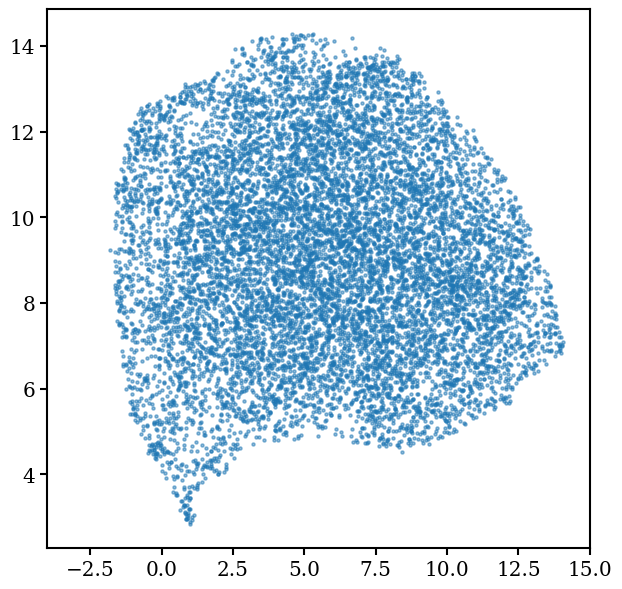

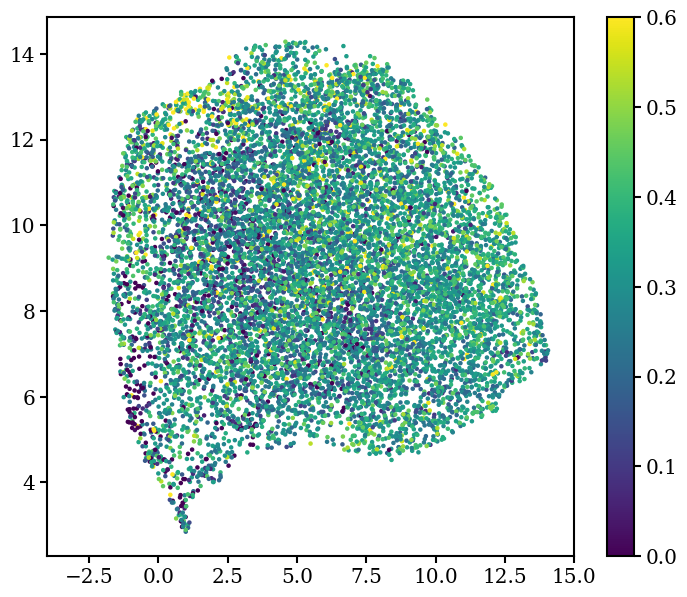

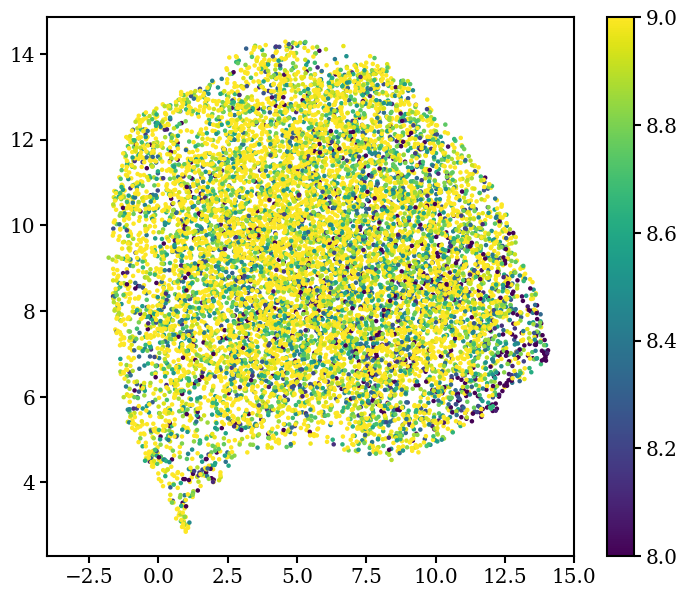

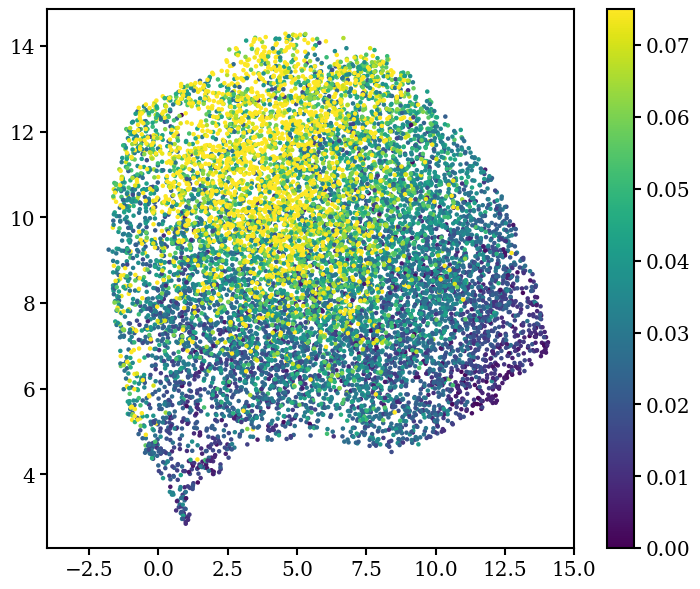

In [145]:
plt.figure(figsize = (7,7))
plt.scatter(umaps_recon[:,0],umaps_recon[:,1],s=5,alpha=0.5)
plt.xlim([-4,15])
plt.show()

plt.figure(figsize = (8.5,7))
plt.scatter(umaps_recon[:,0],umaps_recon[:,1],s=5,c=gr_vals,vmin=0.,vmax=0.6)
plt.xlim([-4,15])
plt.colorbar()
plt.show()

plt.figure(figsize = (8.5,7))
plt.scatter(umaps_recon[:,0],umaps_recon[:,1],s=5,c=logm_vals,vmin=8,vmax=9)
plt.xlim([-4,15])
plt.colorbar()
# plt.ylim([-5,10])
plt.show()

plt.figure(figsize = (8.5,7))
plt.scatter(umaps_recon[:,0],umaps_recon[:,1],s=5,c=zreds_vals,vmin=0,vmax=0.075)
plt.xlim([-4,15])
plt.colorbar()
# plt.ylim([-5,10])
plt.show()

Making the PCA varying plots!!

In [61]:
pca_coeffs = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/pca/total_repr_pca_50_recon.npy")


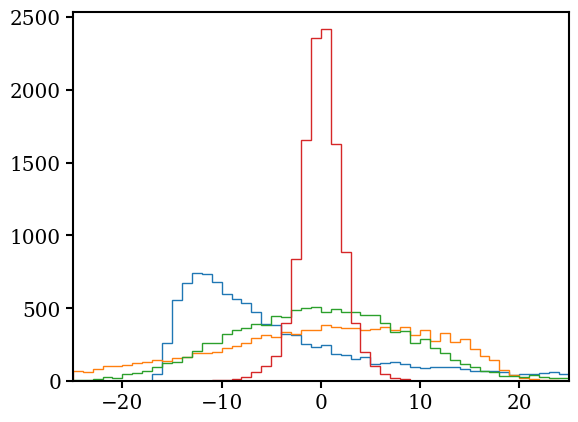

In [80]:
plt.hist(pca_coeffs[:,0],range=(-25,25),bins=50,histtype="step")
plt.hist(pca_coeffs[:,1],range=(-25,25),bins=50,histtype="step")
plt.hist(pca_coeffs[:,4],range=(-25,25),bins=50,histtype="step")
plt.hist(pca_coeffs[:,-1],range=(-25,25),bins=50,histtype="step")
plt.xlim([-25,25])
plt.show()

In [110]:

###
def select_pca_axis_examples(
    repr_pca,
    pc_index=0,
    n_examples=7,
    percentile_range=(0.19, 99.79),
):
    """
    Select indices of galaxies evenly spaced along a PCA axis
    using percentiles (robust to skewness).
    """

    pc_values = repr_pca[:, pc_index]

    percentiles = np.linspace(
        percentile_range[0],
        percentile_range[1],
        n_examples
    )

    targets = np.percentile(pc_values, percentiles)

    selected_indices = [
        np.argmin(np.abs(pc_values - t))
        for t in targets
    ]

    return np.array(selected_indices)


In [137]:
plot_inds = select_pca_axis_examples(pca_coeffs,pc_index=-1,n_examples=10)

In [138]:
tgid_vals[plot_inds]

array([39627890056236853, 39633290604315681, 39627628516215468,
       39627744815877393, 39627853830033445, 39628501468316231,
       39633422594868117, 39633279590077206, 39633562793674549,
       39627957580337597])

In [139]:
tot_cat[plot_inds]["RA","DEC"]

RA,DEC
float64,float64
160.3991172308761,4.336142418651342
269.2637810251379,52.83731498199458
34.2725789938056,-6.511623299835175
141.1147779524244,-1.868653091113424
158.88343572020307,2.8115744710434227
171.87967838493282,31.065167653217685
279.1236632130808,63.11505233986389
277.4359009510513,51.88824062542474
124.72365095260962,82.76201412495047


In [136]:
50+34.1+13.6+2.1

99.79999999999998

In [146]:
TODO: run the similarity search on all z< 20 images and save their representation arrays!!
Make the difference in the redshift between the 20 nearest neighbors vs. random pairs??



SyntaxError: invalid syntax (1081751037.py, line 1)

In [104]:
tot_cat[tot_cat["TARGETID"] == tgid_vals[4682]]["FILE_PATH","MAG_R_BEST"]

FILE_PATH,MAG_R_BEST
bytes128,float64
/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds/south/sweep-320p020-330p025/3251p230/BGS_BRIGHT_tgid_39628331452207801,20.07451236500702


In [111]:
bgsb_cat[bgsb_cat["TARGETID"] == 39628331452207801]["STARFDIST","NEAREST_STAR_NORM_DIST","MAG_TYPE","APER_CEN_MASKED_NO_ISOLATE","APER_CEN_MASKED_ISOLATE"]



STARFDIST,NEAREST_STAR_NORM_DIST,MAG_TYPE,APER_CEN_MASKED_NO_ISOLATE,APER_CEN_MASKED_ISOLATE
float32,float64,object,bool,bool
0.39406183,0.8408339518882698,COG,True,True


4682
325.21752867915626 22.99055604996593
325.21725810402324 22.990933708724
--


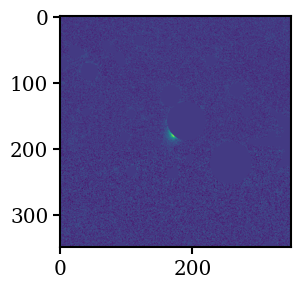

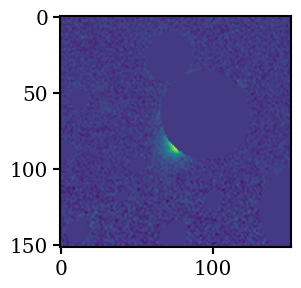

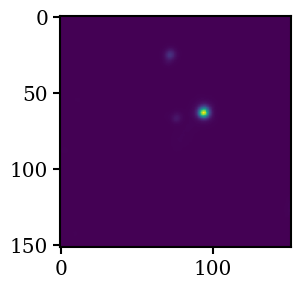

In [103]:
idx = np.where( tot_cat["TARGETID"] == tgid_vals[4682])[0][0]

print(idx)

fp = tot_cat["FILE_PATH"][idx]

#if true, use no isolate
use_no_isolate = tot_cat["ISOLATE_MASK_LIKELY_SHREDDING"][idx]

if use_no_isolate:
    reconst_img = np.load(fp + "/final_reconstruct_galaxy_subfunction_no_isolate.npy")
else:
    reconst_img = np.load(fp + "/final_reconstruct_galaxy_subfunction.npy")

org_img = fits.open(tot_cat["IMAGE_PATH"][idx])[0].data

wcs = WCS(fits.getheader( tot_cat["IMAGE_PATH"][idx] ))

#need to recenter the image
#compute the shift between target_pos and 
ra_cen_i = tot_cat["RA"][idx]
dec_cen_i = tot_cat["DEC"][idx]
ra_tgt_i = tot_cat["RA_TARGET"][idx]
dec_tgt_i = tot_cat["DEC_TARGET"][idx]

print(ra_cen_i, dec_cen_i)
print(ra_tgt_i, dec_tgt_i) 
print("--")

x_cen, y_cen,_ =  wcs.all_world2pix(ra_cen_i, dec_cen_i, 0,1)
x_tgt, y_tgt,_ = wcs.all_world2pix(ra_tgt_i, dec_tgt_i,0, 1)

x_shift = int(np.round(x_cen - x_tgt))
y_shift = int(np.round(y_cen - y_tgt))

plt.figure(figsize = (3,3))
plt.imshow(reconst_img[0])
plt.show()

_, reconst_img  = process_img_shift(reconst_img, cutout_size=152, org_size=np.shape(reconst_img)[1], 
                                    return_shift=False, x_shift=x_shift, y_shift=y_shift)

_, org_img  = process_img_shift(org_img, cutout_size=152, org_size=np.shape(org_img)[1], 
                                    return_shift=False, x_shift=x_shift, y_shift=y_shift)

plt.figure(figsize = (3,3))
plt.imshow(reconst_img[0])
plt.show()

plt.figure(figsize = (3,3))
plt.imshow(org_img[0])
plt.show()